# Grammar Scoring Engine for Spoken Audio

**Task:** predict a continuous MOS grammar score (0-5) from a 45-60 s audio clip.
**Metrics:** RMSE and Pearson correlation. 769 training clips and 216 test clips.

## Report summary (approach)
Grammar is a property of *what* is said and *how fluently* it is said, so I use three complementary views of each clip:

| View | How it is obtained | Why it helps |
|---|---|---|
| **Transcript text** | Whisper ASR | Grammar can only be judged on words. |
| **Text features** | Hand-crafted stats (sentence length, fillers, repetitions, lexical variety, clause markers), GPT-2 perplexity, optional LanguageTool error rate | Directly reflect rubric items: sentence structure, complexity, incomplete sentences, self-correction. |
| **Text embeddings** | RoBERTa mean-pooled embeddings of the transcript | Captures syntax and style beyond hand-made features. |
| **Acoustic embeddings and prosody** | wav2vec2 mean-pooled embeddings plus pause and speech-rate statistics | Captures fluency and hesitation, which correlate with grammatical control. |

**Pipeline:** audio -> 16 kHz mono -> Whisper transcript -> feature blocks -> one base regressor per block (Ridge, SVR, Gradient Boosting) -> out-of-fold predictions -> non-negative linear stacking -> clip to [0, 5].
**Validation:** 5-fold CV out-of-fold (OOF) predictions are the honest estimate. The **training RMSE** (model fitted on all training data and evaluated on the same data) is also reported, as the competition requires. It will be optimistic.

> **Caveat:** Whisper tends to "clean up" speech (it may drop fillers or fix small errors). That removes some grammar-error signal, which is why the acoustic and prosody blocks are included as a complement.

## v4 upgrades (what changed vs v3)
| Upgrade | Why |
|---|---|
| Whisper-large-v3 and WavLM-large layer-wise embeddings | different, stronger views of the audio; audio blocks were the best signal in v3 |
| Verbatim-prompted Whisper transcript + ASR token-confidence features | recovers disfluencies / broken sentences that normal Whisper cleans up |
| Grammar-error-correction edit ratio switched on (`USE_GEC=True`) | most direct grammar-error feature |
| Tuned SVR (grid search inside each fold) on PCA of the best layers, multi-layer concatenations, wider Ridge alpha grid | v3 SVR was untuned; RidgeCV grid may have hit its edge |
| **Attention-pooling neural head on frame-level Whisper features** (5-fold, seeds averaged) | mean/std pooling throws away sentence-level temporal structure |
| Nested cross-validated stacking + optional linear calibration | honest performance estimate; fixes shrinkage toward the mean |
| Self-filling report cell (section 8) | numbers in the report always match the last run |


In [1]:
# If running on Kaggle/Colab, uncomment:
# !pip install -q transformers librosa soundfile scikit-learn scipy pandas matplotlib seaborn tqdm
# Optional (needs Java + internet): !pip install -q language-tool-python

In [2]:
!pip install -q transformers librosa soundfile scikit-learn scipy pandas matplotlib seaborn tqdm

In [3]:
import os, re, json, warnings, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import librosa, torch
from tqdm.auto import tqdm
from scipy.stats import pearsonr
from scipy.optimize import nnls
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 1. Configuration and data loading

In [4]:
# ---- KAGGLE PATHS (edit if your layout differs) ----
BASE_PATH   = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"
DATA_DIR    = BASE_PATH
TRAIN_AUDIO = os.path.join(BASE_PATH, "train")
TEST_AUDIO  = os.path.join(BASE_PATH, "test")
CACHE_DIR   = "/kaggle/working/cache"; os.makedirs(CACHE_DIR, exist_ok=True)

# ---- PRETRAINED MODELS ----
# If Kaggle internet is OFF, attach the models through "Add Input -> Models" and put their local paths here,
# e.g. WHISPER_MODEL = "/kaggle/input/whisper/transformers/small/1"
WHISPER_MODEL = "openai/whisper-small"      # whisper-medium is better if the GPU time allows
WHISPER_MED   = "openai/whisper-medium"     # used for the layer-wise encoder embeddings (strongest block)
LM_MODEL      = "gpt2"
TEXT_ENC      = "roberta-base"
AUDIO_ENC     = "facebook/wav2vec2-base-960h"
GEC_MODEL     = "vennify/t5-base-grammar-correction"
USE_LANGUAGETOOL = False                    # needs Java + internet
USE_GEC          = True                     # grammar-error-correction edit-ratio feature (slowish, needs the model)
WHISPER_LARGE = "openai/whisper-large-v3"   # v4: stronger encoder (if Kaggle runs out of memory use "openai/whisper-large-v2")
WAVLM_LARGE   = "microsoft/wavlm-large"      # v4: second encoder family
SR = 16000

train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sub   = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
FILE_COL, LABEL_COL = "filename", "label"
print(train.shape, test.shape, sub.shape)
train.head()

(769, 2) (216, 2) (204, 2)


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0


In [5]:
def resolve(name, folder):
    # robustly find the wav file (handles missing extension / flat folder layouts)
    for cand in [name, name + ".wav"]:
        for base in [folder, DATA_DIR]:
            p = os.path.join(base, cand)
            if os.path.exists(p): return p
    raise FileNotFoundError(f"{name} not found under {folder}")

train["path"] = [resolve(n, TRAIN_AUDIO) for n in train[FILE_COL]]
test["path"]  = [resolve(n, TEST_AUDIO)  for n in test[FILE_COL]]
y = train[LABEL_COL].values.astype(float)
print(train[LABEL_COL].describe())

count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64


## 2. Exploratory analysis

  0%|          | 0/769 [00:00<?, ?it/s]

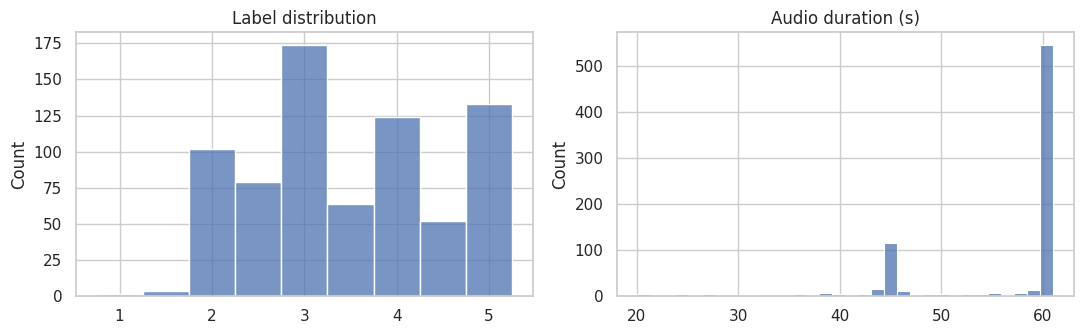

Baseline RMSE (always predict the mean): 1.2382


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(y, bins=np.arange(0.75, 5.5, 0.5), ax=ax[0]); ax[0].set_title("Label distribution")
dur = [librosa.get_duration(path=p) for p in tqdm(train.path)]
sns.histplot(dur, ax=ax[1]); ax[1].set_title("Audio duration (s)")
plt.tight_layout(); plt.show()
print("Baseline RMSE (always predict the mean):", np.sqrt(np.mean((y - y.mean())**2)).round(4))

## 3. Preprocessing: audio loading and ASR transcription
Audio is resampled to 16 kHz mono and peak-normalised. Whisper transcribes each clip (30 s chunks, stitched). Transcripts are cached to disk so the step runs only once.

In [7]:
def load_audio(path):
    wav, _ = librosa.load(path, sr=SR, mono=True)
    peak = np.max(np.abs(wav)) + 1e-9
    return (wav / peak).astype(np.float32)

def cached(name, fn):
    p = os.path.join(CACHE_DIR, name)
    if os.path.exists(p):
        return pd.read_pickle(p)
    out = fn(); pd.to_pickle(out, p); return out

def transcribe_all(paths):
    from transformers import pipeline
    asr = pipeline("automatic-speech-recognition", model=WHISPER_MODEL, device=0 if DEVICE == "cuda" else -1,
                   chunk_length_s=30, torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32)
    texts = []
    for p in tqdm(paths, desc="ASR"):
        out = asr({"raw": load_audio(p), "sampling_rate": SR},
                  generate_kwargs={"language": "en", "task": "transcribe"})
        texts.append(out["text"].strip())
    del asr; torch.cuda.empty_cache()
    return texts

train["text"] = cached("train_text.pkl", lambda: transcribe_all(train.path))
test["text"]  = cached("test_text.pkl",  lambda: transcribe_all(test.path))
for i in range(3): print(f"[score {y[i]}]", train.text[i][:300], "\n")

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  967MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

...

[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


ASR:   0%|          | 0/216 [00:00<?, ?it/s]

[score 3.0] The playground is very, very beautiful and fun. There are places like the merry-go-round, the swing. The students usually enjoy the swing. It has to be like, it's more like a game of pair, because one fits in it and the other fits in it, we'll have to push and may go around to just find points and m 

[score 3.0] The scene of a school playground. Our playground looks like a very big playground having a more greenery trees. In which we students like to garden more trees to have fresh air and all having fresh oxygen. These in the playground these trees gives a very greenery view which will very pleasant to our 

[score 3.5] My favorite place to visit is the beach. I love the sound of the waves crashing against the shore. The feeling of the sand between my toys and the small smell of the salt water. I love the fact that there is always something to do at the beach. I can swim, sun bath, build sandcastle or just relax an 



## 4. Feature engineering
### 4a. Text and prosody features (hand-crafted)
Each feature maps to a rubric idea: sentence structure (sentence length, incomplete sentences), grammatical range (clause markers, tense variety, lexical diversity), accuracy and self-correction (repetitions, fillers, restarts) and fluency (pauses, speech rate).

In [8]:
FILLERS = {"um","uh","uhm","er","erm","hmm","mm","ah"}
SUBORD  = {"because","although","though","while","whereas","if","unless","since","when","whenever","which","who","whom","whose","that","where","after","before","until","so"}
CONJ    = {"and","but","or","yet","nor"}
AUX     = {"is","are","was","were","be","been","being","am","have","has","had","do","does","did","will","would","can","could","should","may","might","must"}
IRREG_PAST = {"went","saw","took","made","came","got","had","did","said","gave","found","thought","told","knew","ate","bought","felt","left","met","began","brought"}

def text_feats(t):
    t = t or ""
    words = re.findall(r"[a-zA-Z']+", t.lower())
    sents = [s for s in re.split(r"[.!?]+", t) if s.strip()]
    n = max(len(words), 1); ns = max(len(sents), 1)
    sl = [len(re.findall(r"[a-zA-Z']+", s)) for s in sents] or [0]
    rep = sum(1 for a, b in zip(words, words[1:]) if a == b)                       # immediate repetitions
    rep2 = sum(1 for a, b, c, d in zip(words, words[1:], words[2:], words[3:]) if (a, b) == (c, d))  # repeated bigrams (restarts)
    return {
        "n_words": len(words), "n_sents": len(sents), "avg_sent_len": np.mean(sl), "std_sent_len": np.std(sl),
        "max_sent_len": max(sl), "short_sent_ratio": np.mean([l <= 3 for l in sl]),
        "ttr": len(set(words)) / n, "avg_word_len": np.mean([len(w) for w in words]) if words else 0,
        "long_word_ratio": np.mean([len(w) >= 7 for w in words]) if words else 0,
        "filler_ratio": sum(w in FILLERS for w in words) / n, "rep_ratio": rep / n, "rep_bigram": rep2,
        "subord_ratio": sum(w in SUBORD for w in words) / n, "conj_ratio": sum(w in CONJ for w in words) / n,
        "aux_ratio": sum(w in AUX for w in words) / n,
        "past_ratio": (sum(w.endswith("ed") for w in words) + sum(w in IRREG_PAST for w in words)) / n,
        "ing_ratio": sum(w.endswith("ing") for w in words) / n, "contraction_ratio": t.count("'") / n,
        "comma_per_sent": t.count(",") / ns, "dash_or_ellipsis": (t.count("-") + t.count("...")) / ns,
        "unique_bigram_ratio": len(set(zip(words, words[1:]))) / max(n - 1, 1),
        "i_ratio": words.count("i") / n,
    }

def prosody_feats(path):
    wav = load_audio(path); dur = len(wav) / SR
    iv = librosa.effects.split(wav, top_db=30)
    seg = np.array([(e - s) / SR for s, e in iv]) if len(iv) else np.array([0.0])
    gaps = np.array([(iv[i+1][0] - iv[i][1]) / SR for i in range(len(iv) - 1)]) if len(iv) > 1 else np.array([0.0])
    long_p = gaps[gaps > 0.4]
    return {"duration": dur, "speech_ratio": seg.sum() / dur, "n_segments": len(iv), "mean_seg": seg.mean(),
            "mean_gap": gaps.mean(), "max_gap": gaps.max(), "n_long_pauses": len(long_p),
            "long_pause_rate": len(long_p) / dur * 60}

def build_hand(df):
    rows = []
    for t, p in tqdm(zip(df.text, df.path), total=len(df), desc="hand feats"):
        f = text_feats(t); f.update(prosody_feats(p)); f["wpm"] = f["n_words"] / f["duration"] * 60
        f["articulation_rate"] = f["n_words"] / max(f["duration"] * f["speech_ratio"], 1e-3)
        rows.append(f)
    return pd.DataFrame(rows)

H_tr = cached("hand_train.pkl", lambda: build_hand(train))
H_te = cached("hand_test.pkl",  lambda: build_hand(test))
H_tr.head(3)

hand feats:   0%|          | 0/769 [00:00<?, ?it/s]

hand feats:   0%|          | 0/216 [00:00<?, ?it/s]

,n_words,n_sents,avg_sent_len,std_sent_len,max_sent_len,short_sent_ratio,ttr,avg_word_len,long_word_ratio,filler_ratio,...,duration,speech_ratio,n_segments,mean_seg,mean_gap,max_gap,n_long_pauses,long_pause_rate,wpm,articulation_rate
0,97,6,16.166667,11.739061,41,0.0,0.649485,4.020619,0.113402,0.0,...,60.508375,0.581209,38,0.925474,0.568216,2.688,16,15.865572,96.185032,2.758189
1,107,7,15.285714,4.948717,22,0.0,0.476636,4.401869,0.149533,0.0,...,60.074688,0.858842,51,1.011661,0.142720,1.408,3,2.996270,106.866973,2.073857
2,146,12,12.166667,3.312434,18,0.0,0.520548,3.979452,0.130137,0.0,...,60.074688,0.754794,43,1.054512,0.330667,2.464,11,10.986324,145.818486,3.219831


### 4b. Language-model fluency (GPT-2 perplexity) and optional grammar-checker errors
Ungrammatical or broken sentences get higher perplexity under a pre-trained LM. Mean, std and 90th-percentile token loss are used.

In [9]:
def lm_feats(texts):
    from transformers import AutoTokenizer, AutoModelForCausalLM
    tok = AutoTokenizer.from_pretrained(LM_MODEL); lm = AutoModelForCausalLM.from_pretrained(LM_MODEL).to(DEVICE).eval()
    out = []
    for t in tqdm(texts, desc="GPT-2"):
        ids = tok(t or ".", return_tensors="pt", truncation=True, max_length=1024).input_ids.to(DEVICE)
        with torch.no_grad():
            logits = lm(ids).logits[0, :-1]
        loss = torch.nn.functional.cross_entropy(logits, ids[0, 1:], reduction="none").cpu().numpy()
        if len(loss) == 0: loss = np.array([0.0])
        out.append({"lm_mean": loss.mean(), "lm_std": loss.std(), "lm_p90": np.percentile(loss, 90),
                    "lm_median": np.median(loss), "lm_max": loss.max()})
    del lm; torch.cuda.empty_cache()
    return pd.DataFrame(out)

def lt_feats(texts):
    import language_tool_python
    tool = language_tool_python.LanguageTool("en-US"); out = []
    for t in tqdm(texts, desc="LanguageTool"):
        m = tool.check(t or ""); n = max(len(re.findall(r"\w+", t or "")), 1)
        out.append({"lt_err_per_word": len(m) / n, "lt_grammar_err": sum("GRAMMAR" in x.ruleId or x.category == "GRAMMAR" for x in m) / n})
    return pd.DataFrame(out)

L_tr = cached("lm_train.pkl", lambda: lm_feats(train.text)); L_te = cached("lm_test.pkl", lambda: lm_feats(test.text))
if USE_LANGUAGETOOL:
    L_tr = pd.concat([L_tr, cached("lt_train.pkl", lambda: lt_feats(train.text))], axis=1)
    L_te = pd.concat([L_te, cached("lt_test.pkl",  lambda: lt_feats(test.text))], axis=1)

X_hand_tr = pd.concat([H_tr, L_tr], axis=1); X_hand_te = pd.concat([H_te, L_te], axis=1)
print("Hand-crafted feature matrix:", X_hand_tr.shape)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2:   0%|          | 0/769 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2:   0%|          | 0/216 [00:00<?, ?it/s]

Hand-crafted feature matrix: (769, 37)


### 4c. Transcript embeddings (RoBERTa) and acoustic embeddings (wav2vec2)

In [10]:
def text_embed(texts):
    from transformers import AutoTokenizer, AutoModel
    tok = AutoTokenizer.from_pretrained(TEXT_ENC); m = AutoModel.from_pretrained(TEXT_ENC).to(DEVICE).eval()
    out = []
    for t in tqdm(texts, desc="RoBERTa"):
        b = tok(t or ".", return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
        with torch.no_grad(): h = m(**b).last_hidden_state[0]
        out.append(h.mean(0).cpu().numpy())
    del m; torch.cuda.empty_cache(); return np.vstack(out)

def audio_embed(paths, layer=6):
    # mid-layer wav2vec2 features carry phonetic/fluency information; mean+std pooled over time
    from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model
    fe = Wav2Vec2FeatureExtractor.from_pretrained(AUDIO_ENC); m = Wav2Vec2Model.from_pretrained(AUDIO_ENC).to(DEVICE).eval()
    out = []
    for p in tqdm(paths, desc="wav2vec2"):
        wav = load_audio(p)[: SR * 60]
        inp = fe(wav, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE)
        with torch.no_grad(): hs = m(inp, output_hidden_states=True).hidden_states[layer][0]
        out.append(torch.cat([hs.mean(0), hs.std(0)]).cpu().numpy())
    del m; torch.cuda.empty_cache(); return np.vstack(out)

E_text_tr = cached("etext_train.pkl", lambda: text_embed(train.text)); E_text_te = cached("etext_test.pkl", lambda: text_embed(test.text))
E_aud_tr  = cached("eaud_train.pkl",  lambda: audio_embed(train.path)); E_aud_te  = cached("eaud_test.pkl",  lambda: audio_embed(test.path))
print(E_text_tr.shape, E_aud_tr.shape)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

wav2vec2:   0%|          | 0/769 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


wav2vec2:   0%|          | 0/216 [00:00<?, ?it/s]

(769, 768) (769, 1536)


### 4c-2. Classic acoustic features and Whisper-encoder embeddings
- The 39 MFCC/spectral/RMS statistics from the earlier ExtraTrees experiment (CV RMSE about 0.76 on their own).
- Whisper-encoder embeddings: the encoder was trained on 680k hours of speech and encodes both content and fluency, so it is usually a stronger acoustic representation than MFCCs.

In [11]:
def acoustic_feats(path):
    y_, sr = librosa.load(path, sr=SR, mono=True)
    rms = librosa.feature.rms(y=y_)[0]; zcr = librosa.feature.zero_crossing_rate(y_)[0]
    cen = librosa.feature.spectral_centroid(y=y_, sr=sr)[0]; bw = librosa.feature.spectral_bandwidth(y=y_, sr=sr)[0]
    ro = librosa.feature.spectral_rolloff(y=y_, sr=sr)[0]; mf = librosa.feature.mfcc(y=y_, sr=sr, n_mfcc=13)
    f = {"duration": len(y_) / sr, "rms_mean": rms.mean(), "rms_std": rms.std(), "rms_min": rms.min(), "rms_max": rms.max(),
         "zcr_mean": zcr.mean(), "zcr_std": zcr.std(), "cen_mean": cen.mean(), "cen_std": cen.std(),
         "bw_mean": bw.mean(), "bw_std": bw.std(), "ro_mean": ro.mean(), "ro_std": ro.std()}
    for i in range(13): f[f"mfcc{i+1}_mean"] = mf[i].mean(); f[f"mfcc{i+1}_std"] = mf[i].std()
    return f

A_tr = cached("acoustic_train.pkl", lambda: pd.DataFrame([acoustic_feats(p) for p in tqdm(train.path, desc="acoustic")]))
A_te = cached("acoustic_test.pkl",  lambda: pd.DataFrame([acoustic_feats(p) for p in tqdm(test.path,  desc="acoustic")]))

def whisper_enc_embed(paths):
    from transformers import WhisperFeatureExtractor, WhisperModel
    fe = WhisperFeatureExtractor.from_pretrained(WHISPER_MODEL)
    enc = WhisperModel.from_pretrained(WHISPER_MODEL).encoder.to(DEVICE).eval()
    out = []
    for p in tqdm(paths, desc="Whisper encoder"):
        wav = load_audio(p); vecs, wts = [], []
        for i in range(0, len(wav), 30 * SR):                       # Whisper window = 30 s
            ch = wav[i:i + 30 * SR]
            if len(ch) < SR: continue
            feats = fe(ch, sampling_rate=SR, return_tensors="pt").input_features.to(DEVICE)
            with torch.no_grad(): hs = enc(feats, output_hidden_states=True).hidden_states
            n = max(int(len(ch) / SR * 50), 1)                      # 50 encoder frames per second (ignore padding)
            vecs.append(torch.cat([hs[len(hs) // 2][0, :n].mean(0), hs[-1][0, :n].mean(0)]).cpu().numpy()); wts.append(n)
        out.append(np.average(np.vstack(vecs), axis=0, weights=wts))
    del enc; torch.cuda.empty_cache(); return np.vstack(out)

E_wh_tr = cached("ewh_train.pkl", lambda: whisper_enc_embed(train.path)); E_wh_te = cached("ewh_test.pkl", lambda: whisper_enc_embed(test.path))

def gec_feats(texts):
    # edit ratio between transcript and its automatically corrected version: more edits = more grammar errors
    import difflib
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
    tok = AutoTokenizer.from_pretrained(GEC_MODEL); m = AutoModelForSeq2SeqLM.from_pretrained(GEC_MODEL).to(DEVICE).eval(); out = []
    for t in tqdm(texts, desc="GEC"):
        sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", t or "") if s.strip()] or ["."]
        ed, nw = 0, 0
        for s_ in sents:
            ids = tok("grammar: " + s_, return_tensors="pt", truncation=True, max_length=128).to(DEVICE)
            with torch.no_grad(): g = m.generate(**ids, max_length=128, num_beams=4)
            c = tok.decode(g[0], skip_special_tokens=True).split(); o = s_.split()
            ed += sum(max(i2 - i1, j2 - j1) for tag, i1, i2, j1, j2 in difflib.SequenceMatcher(None, o, c).get_opcodes() if tag != "equal"); nw += len(o)
        out.append({"gec_edit_ratio": ed / max(nw, 1)})
    del m; torch.cuda.empty_cache(); return pd.DataFrame(out)

if USE_GEC:
    G_tr = cached("gec_train.pkl", lambda: gec_feats(train.text)); G_te = cached("gec_test.pkl", lambda: gec_feats(test.text))
    X_hand_tr = pd.concat([X_hand_tr, G_tr], axis=1); X_hand_te = pd.concat([X_hand_te, G_te], axis=1)
print(A_tr.shape, E_wh_tr.shape)

acoustic:   0%|          | 0/769 [00:00<?, ?it/s]

acoustic:   0%|          | 0/216 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Whisper encoder:   0%|          | 0/769 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

...

model.safetensors: downloading bytes:           |  0.00B            

GEC:   0%|          | 0/769 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

GEC:   0%|          | 0/216 [00:00<?, ?it/s]

(769, 39) (769, 1536)


### 4d. Which hand-crafted features relate to the score?

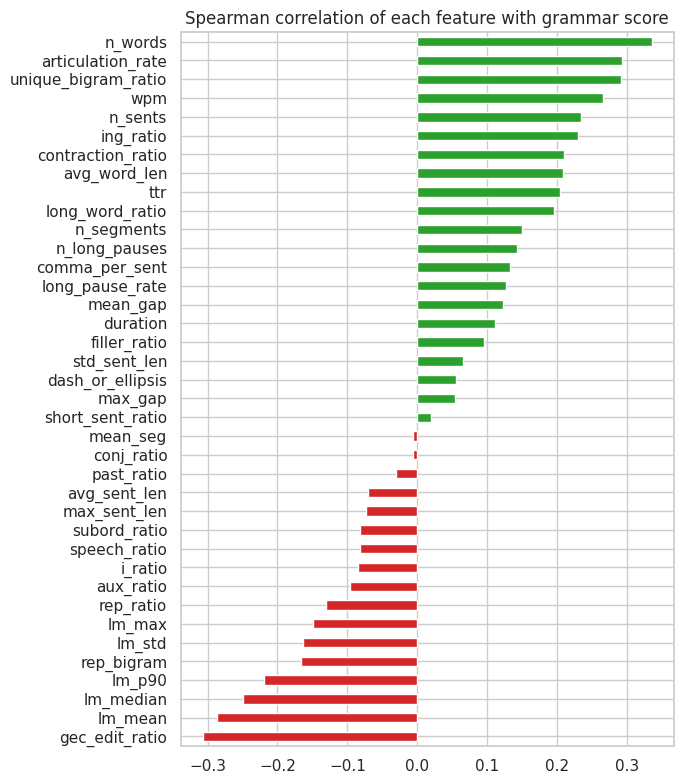

In [12]:
corr = X_hand_tr.assign(label=y).corr(method="spearman")["label"].drop("label").sort_values()
plt.figure(figsize=(7, 8)); corr.plot.barh(color=np.where(corr > 0, "tab:green", "tab:red"))
plt.title("Spearman correlation of each feature with grammar score"); plt.tight_layout(); plt.show()

### 4c-3. Whisper-medium encoder: embeddings from every layer
Layer-wise mean+std pooled encoder states (50 frames/s, padding ignored, 30 s windows averaged). Different layers capture different information, so the layers are scored individually and the best ones become separate models in the stack. This was the strongest signal in my experiments (single layers reach OOF RMSE of about 0.54-0.55).

In [13]:
def whisper_all_layers(paths, name=WHISPER_MED):
    from transformers import WhisperFeatureExtractor, WhisperModel
    fe = WhisperFeatureExtractor.from_pretrained(name)
    enc = WhisperModel.from_pretrained(name, torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32).encoder.to(DEVICE).eval()
    out = []
    for p in tqdm(paths, desc=name):
        wav = load_audio(p); per_chunk, wts = [], []
        for i in range(0, len(wav), 30 * SR):
            ch = wav[i:i + 30 * SR]
            if len(ch) < SR: continue
            f = fe(ch, sampling_rate=SR, return_tensors="pt").input_features.to(DEVICE, enc.dtype)
            with torch.no_grad(): hs = enc(f, output_hidden_states=True).hidden_states
            n = max(int(len(ch) / SR * 50), 1)
            per_chunk.append(torch.stack([torch.cat([h[0, :n].mean(0), h[0, :n].std(0)]) for h in hs]).float().cpu().numpy()); wts.append(n)
        out.append(np.average(np.stack(per_chunk), axis=0, weights=wts))
    del enc; torch.cuda.empty_cache(); return np.stack(out)          # shape (N, n_layers+1, 2*dim)

WL_tr = cached("wlayers_train.pkl", lambda: whisper_all_layers(train.path))
WL_te = cached("wlayers_test.pkl",  lambda: whisper_all_layers(test.path))
print(WL_tr.shape, WL_te.shape)

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.99k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.06GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

openai/whisper-medium:   0%|          | 0/769 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

openai/whisper-medium:   0%|          | 0/216 [00:00<?, ?it/s]

(769, 25, 2048) (216, 25, 2048)


,layer,RMSE,Pearson
0,0,0.7985,0.7622
1,2,0.6912,0.8274
2,4,0.6465,0.8510
3,6,0.6395,0.8543
4,8,0.6117,0.8669
5,10,0.5864,0.8782
6,12,0.5612,0.8890
7,14,0.5703,0.8844
8,16,0.5510,0.8932
9,18,0.5506,0.8932


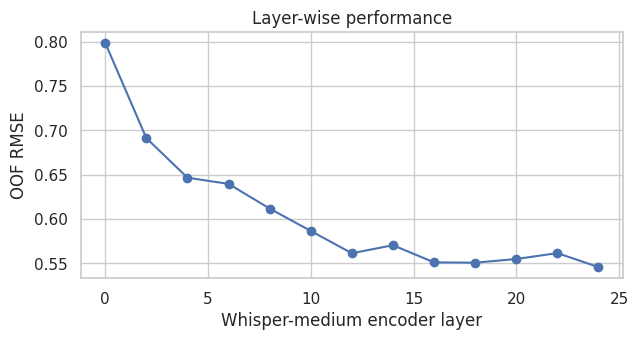

In [14]:
# Layer scan: which encoder layers predict the grammar score best? (5-fold CV, Ridge with alpha chosen by CV)
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import RidgeCV
_ridge = lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(0, 6, 13)))
scan = []
for L in range(0, WL_tr.shape[1], 2):
    p = cross_val_predict(_ridge(), WL_tr[:, L], y, cv=KFold(5, shuffle=True, random_state=SEED))
    scan.append((L, float(np.sqrt(np.mean((y - np.clip(p, 0, 5)) ** 2))), pearsonr(y, p)[0]))
scan = pd.DataFrame(scan, columns=["layer", "RMSE", "Pearson"]); display(scan.round(4))
fig, ax = plt.subplots(figsize=(7, 3.2)); ax.plot(scan.layer, scan.RMSE, "o-"); ax.set(xlabel="Whisper-medium encoder layer", ylabel="OOF RMSE", title="Layer-wise performance"); plt.show()

### 4c-4. NEW: Whisper-large-v3 and WavLM-large encoder layers
Same pooling as the Whisper-medium layers (mean+std per layer). Both are cached, so this runs once (roughly 20-30 min for Whisper-large-v3 and 10 min for WavLM-large on a T4).

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

...

model.safetensors: downloading bytes:           |  0.00B            

microsoft/wavlm-large:   0%|          | 0/769 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

microsoft/wavlm-large:   0%|          | 0/216 [00:00<?, ?it/s]

whisper-large-v3: (769, 33, 2560) | wavlm-large: (769, 25, 2048)


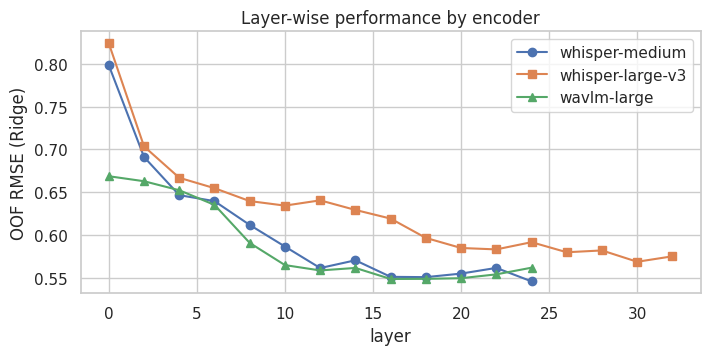

Best whisper-large-v3 layers:


,layer,RMSE,Pearson
15,30,0.5686,0.8866
16,32,0.5750,0.8836
13,26,0.5797,0.8814
14,28,0.5819,0.8806
11,22,0.5831,0.8793


Best wavlm-large layers:


,layer,RMSE,Pearson
8,16,0.5485,0.8949
9,18,0.5486,0.8954
10,20,0.5493,0.8956
11,22,0.5539,0.8931
6,12,0.5585,0.8913


In [15]:
_rm = lambda a, b: float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

WL3_tr = cached("wl3_train.pkl", lambda: whisper_all_layers(train.path, WHISPER_LARGE))   # whisper_all_layers takes a model name
WL3_te = cached("wl3_test.pkl",  lambda: whisper_all_layers(test.path,  WHISPER_LARGE))

def hf_audio_layers(paths, name, max_sec=60):
    """Mean+std pooled hidden state of EVERY layer of a generic HF speech encoder -> (N, n_layers+1, 2*dim)."""
    from transformers import AutoFeatureExtractor, AutoModel
    dt = torch.float16 if DEVICE == "cuda" else torch.float32
    fe = AutoFeatureExtractor.from_pretrained(name)
    m = AutoModel.from_pretrained(name, torch_dtype=dt).to(DEVICE).eval()
    out = []
    for p in tqdm(paths, desc=name):
        wav = load_audio(p)[: SR * max_sec]
        inp = fe(wav, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE, dt)
        with torch.no_grad(): hs = m(inp, output_hidden_states=True).hidden_states
        out.append(torch.stack([torch.cat([h[0].float().mean(0), h[0].float().std(0)]) for h in hs]).cpu().numpy())
    del m; torch.cuda.empty_cache(); return np.stack(out)

WV_tr = cached("wavlm_train.pkl", lambda: hf_audio_layers(train.path, WAVLM_LARGE))
WV_te = cached("wavlm_test.pkl",  lambda: hf_audio_layers(test.path,  WAVLM_LARGE))
print("whisper-large-v3:", WL3_tr.shape, "| wavlm-large:", WV_tr.shape)

def layer_scan(W, step=2):
    rows = []
    for L in range(0, W.shape[1], step):
        p = cross_val_predict(_ridge(), W[:, L], y, cv=KFold(5, shuffle=True, random_state=SEED))
        rows.append((L, _rm(y, np.clip(p, 0, 5)), pearsonr(y, p)[0]))
    return pd.DataFrame(rows, columns=["layer", "RMSE", "Pearson"])

scan_l3 = layer_scan(WL3_tr); scan_wv = layer_scan(WV_tr)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(scan.layer, scan.RMSE, "o-", label="whisper-medium"); ax.plot(scan_l3.layer, scan_l3.RMSE, "s-", label="whisper-large-v3")
ax.plot(scan_wv.layer, scan_wv.RMSE, "^-", label="wavlm-large")
ax.set(xlabel="layer", ylabel="OOF RMSE (Ridge)", title="Layer-wise performance by encoder"); ax.legend(); plt.show()
print("Best whisper-large-v3 layers:"); display(scan_l3.sort_values("RMSE").head(5).round(4))
print("Best wavlm-large layers:");      display(scan_wv.sort_values("RMSE").head(5).round(4))

### 4c-5. NEW: verbatim-prompted transcript and ASR confidence
Normal Whisper tends to delete fillers, repetitions and restarts. A disfluent prompt makes it keep them. Token log-probabilities measure how surprising the speech was to the ASR model; broken or ungrammatical speech tends to lower confidence. Hand-crafted and GPT-2 features are recomputed on this verbatim transcript.

In [16]:
import transformers; transformers.logging.set_verbosity_error()
VERBATIM_PROMPT = "Umm, let me think like, hmm... Okay, here's what I'm, like, thinking. I- I was, uh, going to the the store and, you know, we went."

def whisper_verbatim_conf(paths, name=WHISPER_MED):
    from transformers import WhisperProcessor, WhisperForConditionalGeneration
    dt = torch.float16 if DEVICE == "cuda" else torch.float32
    proc = WhisperProcessor.from_pretrained(name)
    model = WhisperForConditionalGeneration.from_pretrained(name, torch_dtype=dt).to(DEVICE).eval()
    prompt_ids = proc.get_prompt_ids(VERBATIM_PROMPT, return_tensors="pt").to(DEVICE)
    eos = proc.tokenizer.eos_token_id
    texts, feats = [], []
    for p in tqdm(paths, desc="verbatim ASR"):
        wav = load_audio(p); lps, parts = [], []
        for i in range(0, len(wav), 30 * SR):
            ch = wav[i:i + 30 * SR]
            if len(ch) < SR: continue
            f = proc.feature_extractor(ch, sampling_rate=SR, return_tensors="pt").input_features.to(DEVICE, dt)
            kw = dict(language="en", task="transcribe", num_beams=1, do_sample=False, max_new_tokens=220,
                      return_dict_in_generate=True, output_scores=True)
            with torch.no_grad():
                try:    o = model.generate(f, prompt_ids=prompt_ids, **kw)
                except Exception: o = model.generate(f, **kw)            # fallback without the prompt if this transformers version objects
            toks = o.sequences[0, -len(o.scores):]
            for s, t in zip(o.scores, toks):
                if int(t) < eos:                                         # text tokens only (skip timestamps / specials)
                    lps.append(float(torch.log_softmax(s[0].float(), -1)[t]))
            parts.append(proc.tokenizer.decode(toks, skip_special_tokens=True).replace(VERBATIM_PROMPT, "").strip())
        lp = np.array(lps) if lps else np.array([-5.0])
        texts.append(" ".join(parts))
        feats.append({"asr_lp_mean": lp.mean(), "asr_lp_min": lp.min(), "asr_lp_p10": np.percentile(lp, 10), "asr_lp_std": lp.std(),
                      "asr_low_conf_frac": (lp < -1).mean(), "asr_very_low_frac": (lp < -2.5).mean(), "asr_n_tok": len(lp)})
    del model; torch.cuda.empty_cache()
    return texts, pd.DataFrame(feats)

_vtr = cached("verb_train.pkl", lambda: whisper_verbatim_conf(train.path))
_vte = cached("verb_test.pkl",  lambda: whisper_verbatim_conf(test.path))
train["text_v"], C_tr = _vtr; test["text_v"], C_te = _vte
for i in range(3): print(f"[score {y[i]:.2f}] plain   : {train.text[i][:180]}\n             verbatim: {train.text_v[i][:180]}\n")

def text_only_feats(df): return pd.DataFrame([text_feats(t) for t in df.text_v]).add_prefix("v_")
V_tr = cached("vfeat_train.pkl", lambda: pd.concat([text_only_feats(train), lm_feats(train.text_v).add_prefix("v_")], axis=1))
V_te = cached("vfeat_test.pkl",  lambda: pd.concat([text_only_feats(test),  lm_feats(test.text_v).add_prefix("v_")],  axis=1))
# X_hand_tr already contains the GEC feature when USE_GEC=True
X_hand2_tr = pd.concat([X_hand_tr, C_tr, V_tr], axis=1); X_hand2_te = pd.concat([X_hand_te, C_te, V_te], axis=1)
print("Hand-crafted v2 matrix:", X_hand2_tr.shape)
print(pd.concat([C_tr, V_tr], axis=1).assign(label=y).corr(method="spearman")["label"].drop("label").sort_values().round(3).to_string())

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2:   0%|          | 0/769 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2:   0%|          | 0/216 [00:00<?, ?it/s]

Hand-crafted v2 matrix: (769, 72)
asr_lp_std              -0.396
asr_low_conf_frac       -0.388
v_lm_mean               -0.261
v_rep_bigram            -0.214
v_lm_median             -0.204
v_lm_p90                -0.177
v_rep_ratio             -0.172
asr_very_low_frac       -0.155
v_lm_std                -0.131
v_dash_or_ellipsis      -0.082
v_i_ratio               -0.062
v_conj_ratio            -0.059
v_subord_ratio          -0.059
v_aux_ratio             -0.054
v_comma_per_sent        -0.049
v_filler_ratio          -0.049
v_past_ratio            -0.029
v_lm_max                -0.027
v_short_sent_ratio      -0.001
v_avg_sent_len           0.067
v_std_sent_len           0.095
v_max_sent_len           0.112
v_ttr                    0.166
v_n_sents                0.173
v_long_word_ratio        0.180
v_contraction_ratio      0.181
v_avg_word_len           0.194
asr_n_tok                0.203
v_n_words                0.220
v_ing_ratio              0.222
asr_lp_min               0.224
v_uni

## 5. Modelling: base learners and stacking
One regressor per feature block, so a high-dimensional embedding cannot swamp the small hand-crafted block:

| Block | Model |
|---|---|
| Hand-crafted + LM features | Gradient Boosting (robust to feature scales and non-linearity) |
| RoBERTa transcript embedding | Ridge (strong regularisation for 768 dims and about 770 samples) |
| wav2vec2 embedding | Ridge |
| Classic acoustic stats (MFCC, RMS, spectral) | ExtraTrees |
| Whisper-small encoder; Whisper-medium layers 12, 18, 24 and the layer 16-24 average | Ridge (alpha via RidgeCV) |
| Hand-crafted + RoBERTa + wav2vec2 + Whisper-small (all) | SVR (RBF) on standardised features |

For each learner I get **OOF predictions** with repeated 5-fold CV. A non-negative least-squares stacker learns blend weights from the OOF predictions. Final predictions are clipped to [0, 5].

In [17]:
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import ExtraTreesRegressor
ALPHAS = np.logspace(0, 6, 13)      # v4: wider grid so the chosen alpha is not stuck at the edge
ridge = lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))      # alpha chosen by internal CV, not guessed

blocks = {
    "hand_GBR":    (X_hand_tr.values, X_hand_te.values,
                    lambda: GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.03, subsample=0.8, random_state=SEED)),
    "acoustic_ET": (A_tr.values, A_te.values,
                    lambda: ExtraTreesRegressor(n_estimators=500, min_samples_leaf=2, max_features=0.5, random_state=SEED, n_jobs=-1)),
    "text_Ridge":  (E_text_tr, E_text_te, ridge),
    "w2v_Ridge":   (E_aud_tr,  E_aud_te,  ridge),
    "whisper_Ridge": (E_wh_tr, E_wh_te,   ridge),
    "wm_L12_Ridge": (WL_tr[:, 12], WL_te[:, 12], ridge),
    "wm_L18_Ridge": (WL_tr[:, 18], WL_te[:, 18], ridge),
    "wm_L24_Ridge": (WL_tr[:, 24], WL_te[:, 24], ridge),
    "wm_avg16_24":  (WL_tr[:, 16:25].mean(axis=1), WL_te[:, 16:25].mean(axis=1), ridge),
    "all_SVR":     (np.hstack([X_hand_tr.values, E_text_tr, E_aud_tr, E_wh_tr]),
                    np.hstack([X_hand_te.values, E_text_te, E_aud_te, E_wh_te]),
                    lambda: make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.2, gamma="scale"))),
}
N_REPEATS, N_FOLDS = 3, 5

def oof_predict(Xtr, Xte, make, y):
    oof = np.zeros(len(y))
    for r in range(N_REPEATS):
        for tr_i, va_i in KFold(N_FOLDS, shuffle=True, random_state=SEED + r).split(Xtr):
            m = make().fit(Xtr[tr_i], y[tr_i]); oof[va_i] += m.predict(Xtr[va_i]) / N_REPEATS
    full = make().fit(Xtr, y)                       # model fitted on all training data
    return oof, full.predict(Xtr), full.predict(Xte)

rmse = lambda a, b: float(np.sqrt(mean_squared_error(a, b)))
OOF, TRFIT, TEST = {}, {}, {}
for name, (Xtr, Xte, make) in blocks.items():
    OOF[name], TRFIT[name], TEST[name] = oof_predict(Xtr, Xte, make, y)
    print(f"{name:14s} OOF RMSE={rmse(y, np.clip(OOF[name],0,5)):.4f}  OOF Pearson={pearsonr(y, OOF[name])[0]:.4f}")

hand_GBR       OOF RMSE=0.7811  OOF Pearson=0.7766
acoustic_ET    OOF RMSE=0.7529  OOF Pearson=0.7977
text_Ridge     OOF RMSE=0.8215  OOF Pearson=0.7438
w2v_Ridge      OOF RMSE=0.6143  OOF Pearson=0.8675
whisper_Ridge  OOF RMSE=0.5466  OOF Pearson=0.8954
wm_L12_Ridge   OOF RMSE=0.5471  OOF Pearson=0.8946
wm_L18_Ridge   OOF RMSE=0.5520  OOF Pearson=0.8927
wm_L24_Ridge   OOF RMSE=0.5351  OOF Pearson=0.9002
wm_avg16_24    OOF RMSE=0.5395  OOF Pearson=0.8977
all_SVR        OOF RMSE=0.5456  OOF Pearson=0.9009


### 5b. NEW base learners
All are added to the same `OOF / TRFIT / TEST` dictionaries so that the stacker can use them.
- Ridge on the best layers of Whisper-large-v3 and WavLM-large, and on multi-layer concatenations / bands.
- **SVR tuned by grid search inside every fold** (PCA to 128 dims first) on the best layers.
- Tree models on the v2 hand-crafted block (adds ASR confidence, verbatim-text features and GEC).
- One cross-modal SVR on audio embeddings + v2 hand-crafted features.

In [18]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

top = lambda s, k=3: [int(l) for l in s.sort_values("RMSE").layer.head(k)]
l3_top, wv_top = top(scan_l3), top(scan_wv)
wm_top = top(scan, 1)[0]
print("whisper-large-v3 top layers:", l3_top, "| wavlm top layers:", wv_top, "| whisper-medium best:", wm_top)
band = lambda s: (lambda L: (max(L - 2, 0), L + 3))(int(s.sort_values("RMSE").layer.iloc[0]))

def tuned_svr():
    """PCA -> RBF-SVR, C and epsilon chosen by an inner 3-fold grid search (so no leakage into the outer folds)."""
    pipe = make_pipeline(StandardScaler(), PCA(128, random_state=SEED), SVR(kernel="rbf", gamma="scale"))
    return GridSearchCV(pipe, {"svr__C": [1, 3, 10], "svr__epsilon": [0.1, 0.2]}, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)

new_blocks = {}
for L in l3_top: new_blocks[f"wl3_L{L}_Ridge"] = (WL3_tr[:, L], WL3_te[:, L], ridge)
for L in wv_top: new_blocks[f"wavlm_L{L}_Ridge"] = (WV_tr[:, L], WV_te[:, L], ridge)
a, b = band(scan_l3); new_blocks["wl3_band_Ridge"]   = (WL3_tr[:, a:b].mean(1), WL3_te[:, a:b].mean(1), ridge)
a, b = band(scan_wv); new_blocks["wavlm_band_Ridge"] = (WV_tr[:, a:b].mean(1),  WV_te[:, a:b].mean(1),  ridge)
new_blocks["wm_concat_Ridge"]  = (WL_tr[:, [12, 18, 24]].reshape(len(WL_tr), -1), WL_te[:, [12, 18, 24]].reshape(len(WL_te), -1), ridge)
new_blocks["wl3_concat_Ridge"] = (WL3_tr[:, l3_top].reshape(len(WL3_tr), -1), WL3_te[:, l3_top].reshape(len(WL3_te), -1), ridge)

new_blocks["wm_best_SVRt"]    = (WL_tr[:, wm_top],     WL_te[:, wm_top],     tuned_svr)
new_blocks["wl3_best_SVRt"]   = (WL3_tr[:, l3_top[0]], WL3_te[:, l3_top[0]], tuned_svr)
new_blocks["wavlm_best_SVRt"] = (WV_tr[:, wv_top[0]],  WV_te[:, wv_top[0]],  tuned_svr)
cross_tr = np.hstack([X_hand2_tr.values, WL3_tr[:, l3_top[0]]]); cross_te = np.hstack([X_hand2_te.values, WL3_te[:, l3_top[0]]])
new_blocks["audio+hand2_SVRt"] = (cross_tr, cross_te, tuned_svr)

new_blocks["hand2_GBR"] = (X_hand2_tr.values, X_hand2_te.values, blocks["hand_GBR"][2])
new_blocks["hand2_ET"]  = (X_hand2_tr.values, X_hand2_te.values,
                           lambda: ExtraTreesRegressor(n_estimators=500, min_samples_leaf=2, max_features=0.4, random_state=SEED, n_jobs=-1))

for name, (Xtr, Xte, make) in new_blocks.items():
    OOF[name], TRFIT[name], TEST[name] = oof_predict(np.asarray(Xtr), np.asarray(Xte), make, y)
    print(f"{name:20s} OOF RMSE={rmse(y, np.clip(OOF[name],0,5)):.4f}  OOF Pearson={pearsonr(y, OOF[name])[0]:.4f}")

whisper-large-v3 top layers: [30, 32, 26] | wavlm top layers: [16, 18, 20] | whisper-medium best: 24
wl3_L30_Ridge        OOF RMSE=0.5591  OOF Pearson=0.8908
wl3_L32_Ridge        OOF RMSE=0.5658  OOF Pearson=0.8877
wl3_L26_Ridge        OOF RMSE=0.5673  OOF Pearson=0.8866
wavlm_L16_Ridge      OOF RMSE=0.5284  OOF Pearson=0.9029
wavlm_L18_Ridge      OOF RMSE=0.5341  OOF Pearson=0.9013
wavlm_L20_Ridge      OOF RMSE=0.5394  OOF Pearson=0.8997
wl3_band_Ridge       OOF RMSE=0.5571  OOF Pearson=0.8912
wavlm_band_Ridge     OOF RMSE=0.5265  OOF Pearson=0.9039
wm_concat_Ridge      OOF RMSE=0.5185  OOF Pearson=0.9059
wl3_concat_Ridge     OOF RMSE=0.5509  OOF Pearson=0.8939
wm_best_SVRt         OOF RMSE=0.5468  OOF Pearson=0.8977
wl3_best_SVRt        OOF RMSE=0.5556  OOF Pearson=0.8921
wavlm_best_SVRt      OOF RMSE=0.5339  OOF Pearson=0.9018
audio+hand2_SVRt     OOF RMSE=0.5578  OOF Pearson=0.8912
hand2_GBR            OOF RMSE=0.7021  OOF Pearson=0.8251
hand2_ET             OOF RMSE=0.7382  OOF Pe

### 5c. NEW: attention-pooling neural head on frame-level Whisper features
Mean/std pooling collapses the whole clip into one vector. Here a small network sees the *sequence* of encoder frames (averaged over the best layer band, pooled to 10 frames/s): LayerNorm -> linear projection -> 1 transformer layer -> attention pooling + mean pooling -> MLP. It is trained with MSE on the standardised target, frame dropout and weight decay. Out-of-fold predictions use the same repeated 5-fold scheme as every other block, with 2 seeds per fold.
`TRFIT` (used for the required training RMSE) comes from models fitted on all training data; `TEST` is the average of all fold models.

In [19]:
# ---- choose the better Whisper encoder and its best layer band ----
use_l3 = scan_l3.RMSE.min() < scan.RMSE.min()
FR_NAME = WHISPER_LARGE if use_l3 else WHISPER_MED
_scan, n_hid = (scan_l3, WL3_tr.shape[1]) if use_l3 else (scan, WL_tr.shape[1])
best_L = int(_scan.sort_values("RMSE").layer.iloc[0])
FR_LAYERS = list(range(max(best_L - 2, 1), min(best_L + 3, n_hid)))
print("Frame encoder:", FR_NAME, "| layers averaged:", FR_LAYERS)

def whisper_frames(paths, name, layers, pool=5):
    """Frame-level features (50 fps -> 50/pool fps), averaged over `layers`. Returns a list of (T_i, D) float16 arrays."""
    from transformers import WhisperFeatureExtractor, WhisperModel
    fe = WhisperFeatureExtractor.from_pretrained(name)
    enc = WhisperModel.from_pretrained(name, torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32).encoder.to(DEVICE).eval()
    out = []
    for p in tqdm(paths, desc="frames"):
        wav = load_audio(p); chunks = []
        for i in range(0, len(wav), 30 * SR):
            ch = wav[i:i + 30 * SR]
            if len(ch) < SR: continue
            f = fe(ch, sampling_rate=SR, return_tensors="pt").input_features.to(DEVICE, enc.dtype)
            with torch.no_grad(): hs = enc(f, output_hidden_states=True).hidden_states
            n = max(int(len(ch) / SR * 50), 1)
            h = torch.stack([hs[l][0, :n] for l in layers]).float().mean(0)           # (n, D)
            m = max((n // pool) * pool, pool)
            h = h[:m].reshape(-1, pool, h.shape[-1]).mean(1) if n >= pool else h.mean(0, keepdim=True)
            chunks.append(h)
        out.append(torch.cat(chunks).half().cpu().numpy())
    del enc; torch.cuda.empty_cache(); return out

tag = f"{'l3' if use_l3 else 'wm'}_{FR_LAYERS[0]}-{FR_LAYERS[-1]}"
FR_tr = cached(f"frames_{tag}_train.pkl", lambda: whisper_frames(train.path, FR_NAME, FR_LAYERS))
FR_te = cached(f"frames_{tag}_test.pkl",  lambda: whisper_frames(test.path,  FR_NAME, FR_LAYERS))

# ---- pad everything into one GPU tensor (train rows first, then test rows) ----
FR_all = FR_tr + FR_te; N_TR = len(FR_tr)
Tmax = max(len(a) for a in FR_all); D = FR_all[0].shape[1]
Xg = torch.zeros(len(FR_all), Tmax, D, dtype=torch.float16, device=DEVICE)
Mg = torch.zeros(len(FR_all), Tmax, dtype=torch.bool, device=DEVICE)
for i, a in enumerate(FR_all):
    Xg[i, :len(a)] = torch.from_numpy(a).to(DEVICE); Mg[i, :len(a)] = True
print("Frame tensor:", tuple(Xg.shape), "| mean frames per clip:", int(np.mean([len(a) for a in FR_all])))

class AttnHead(torch.nn.Module):
    """LayerNorm -> projection -> 1 transformer layer -> [attention pooling ; mean pooling] -> MLP -> score."""
    def __init__(s, D, d=256, drop=0.3):
        super().__init__()
        s.norm = torch.nn.LayerNorm(D); s.proj = torch.nn.Linear(D, d); s.drop = torch.nn.Dropout(drop)
        layer = torch.nn.TransformerEncoderLayer(d, 4, 2 * d, drop, batch_first=True, norm_first=True)
        s.enc = torch.nn.TransformerEncoder(layer, 1, enable_nested_tensor=False)
        s.att = torch.nn.Linear(d, 1)
        s.out = torch.nn.Sequential(torch.nn.Linear(2 * d, 128), torch.nn.GELU(), torch.nn.Dropout(drop), torch.nn.Linear(128, 1))
    def forward(s, x, mask):                                   # mask: True = real frame
        h = s.drop(torch.nn.functional.gelu(s.proj(s.norm(x))))
        h = s.enc(h, src_key_padding_mask=~mask)
        a = torch.softmax(s.att(h).squeeze(-1).masked_fill(~mask, -1e4), 1).unsqueeze(-1)
        att = (a * h).sum(1)
        mean = (h * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True)
        return s.out(torch.cat([att, mean], 1)).squeeze(-1)

def train_head(yt, tr_idx, seed, epochs=30, bs=32, lr=4e-4):
    torch.manual_seed(seed); rs = np.random.RandomState(seed)
    m = AttnHead(D).to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=0.05)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=epochs * int(np.ceil(len(tr_idx) / bs)), pct_start=0.15)
    ytt = torch.tensor(yt, dtype=torch.float32, device=DEVICE)
    for ep in range(epochs):
        m.train(); perm = rs.permutation(tr_idx)
        for i in range(0, len(perm), bs):
            b = torch.as_tensor(perm[i:i + bs], device=DEVICE)
            mk = Mg[b] & (torch.rand(Mg[b].shape, device=DEVICE) > 0.1)          # frame dropout (regularisation)
            mk[:, 0] = True
            loss = torch.nn.functional.mse_loss(m(Xg[b].float(), mk), ytt[b])
            opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step(); sched.step()
    return m

def predict_head(m, idx, bs=64):
    m.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(idx), bs):
            b = torch.as_tensor(idx[i:i + bs], device=DEVICE); out.append(m(Xg[b].float(), Mg[b]).cpu().numpy())
    return np.concatenate(out)

def head_oof(seeds=(0, 1), repeats=N_REPEATS, epochs=30):
    ym, ys = y.mean(), y.std(); yt = (y - ym) / ys
    tr_all, te_idx = np.arange(N_TR), np.arange(N_TR, len(FR_all))
    oof = np.zeros(N_TR); te = np.zeros(len(te_idx)); n_te = 0
    for r in range(repeats):
        for k, (tr_i, va_i) in enumerate(KFold(N_FOLDS, shuffle=True, random_state=SEED + r).split(tr_all)):
            for s in seeds:
                m = train_head(yt, tr_i, seed=1000 * r + 10 * k + s, epochs=epochs)
                oof[va_i] += predict_head(m, va_i) / (repeats * len(seeds)); te += predict_head(m, te_idx); n_te += 1
        print(f"  repeat {r+1}/{repeats} done | running OOF RMSE (partial) = {_rm(y, np.clip((oof * repeats / (r + 1)) * ys + ym, 0, 5)):.4f}")
    full = [train_head(yt, tr_all, seed=777 + s, epochs=epochs) for s in (0, 1, 2)]
    trfit = np.mean([predict_head(m, tr_all) for m in full], axis=0)
    return oof * ys + ym, trfit * ys + ym, (te / n_te) * ys + ym

OOF["attn_head"], TRFIT["attn_head"], TEST["attn_head"] = head_oof()
print(f"attn_head  OOF RMSE={rmse(y, np.clip(OOF['attn_head'],0,5)):.4f}  OOF Pearson={pearsonr(y, OOF['attn_head'])[0]:.4f}")

Frame encoder: openai/whisper-medium | layers averaged: [22, 23, 24]


Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

frames:   0%|          | 0/769 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

frames:   0%|          | 0/216 [00:00<?, ?it/s]

Frame tensor: (985, 610, 1024) | mean frames per clip: 541
  repeat 1/3 done | running OOF RMSE (partial) = 0.6359
  repeat 2/3 done | running OOF RMSE (partial) = 0.6097
  repeat 3/3 done | running OOF RMSE (partial) = 0.6031
attn_head  OOF RMSE=0.6031  OOF Pearson=0.8943


## 5d. Stacking
First the **v3 stack** (original 10 blocks) is reproduced for reference. Then the **v4 stack** blends every block with non-negative least squares. Because the blend weights are fitted on OOF predictions, the reported estimate is made honest with **nested cross-validation**: the stacker (and an optional linear calibration that undoes shrinkage toward the mean) is itself cross-validated. The number of blocks used and the calibration are chosen by that nested CV, not by the public leaderboard.

In [20]:
# Non-negative stacking (weights sum normalised) on OOF predictions
names = list(blocks)
A = np.column_stack([OOF[n] for n in names]); w, _ = nnls(np.column_stack([A, np.ones(len(y))]), y)
coef, intercept = w[:-1], w[-1]
print("Stacking weights:", dict(zip(names, coef.round(3))), "| intercept:", round(intercept, 3))

blend = lambda D: np.clip(np.column_stack([D[n] for n in names]) @ coef + intercept, 0, 5)
oof_final, train_final, test_final = blend(OOF), blend(TRFIT), blend(TEST)
v3_oof, v3_train, v3_test = oof_final, train_final, test_final       # kept for comparison / blending later
print(f"v3 stack (10 original blocks): train RMSE={rmse(y, v3_train):.4f} | OOF RMSE={rmse(y, v3_oof):.4f} | OOF Pearson={pearsonr(y, v3_oof)[0]:.4f}")

Stacking weights: {'hand_GBR': np.float64(0.0), 'acoustic_ET': np.float64(0.0), 'text_Ridge': np.float64(0.048), 'w2v_Ridge': np.float64(0.017), 'whisper_Ridge': np.float64(0.0), 'wm_L12_Ridge': np.float64(0.283), 'wm_L18_Ridge': np.float64(0.0), 'wm_L24_Ridge': np.float64(0.285), 'wm_avg16_24': np.float64(0.044), 'all_SVR': np.float64(0.331)} | intercept: 0.0
v3 stack (10 original blocks): train RMSE=0.2851 | OOF RMSE=0.5086 | OOF Pearson=0.9156


In [21]:
from sklearn.linear_model import LinearRegression

def fit_nnls(O, t):
    A_ = np.column_stack([O, np.ones(len(t)), -np.ones(len(t))])        # +/- columns give a signed intercept
    w_, _ = nnls(A_, t); return w_[:-2], w_[-2] - w_[-1]
apply_nnls = lambda O, c, b: O @ c + b

names = list(OOF); O_all = np.column_stack([OOF[n] for n in names])

def cv_stack(O, t, calibrate, seeds=range(5)):
    """Nested CV: fit blend weights (and calibration) on 4/5 of the OOF rows, predict the remaining 1/5."""
    preds = np.zeros((len(seeds), len(t)))
    for si, s in enumerate(seeds):
        for tr_i, va_i in KFold(5, shuffle=True, random_state=100 + s).split(O):
            c, b = fit_nnls(O[tr_i], t[tr_i]); p_va = apply_nnls(O[va_i], c, b)
            if calibrate:
                cal = LinearRegression().fit(apply_nnls(O[tr_i], c, b)[:, None], t[tr_i]); p_va = cal.predict(p_va[:, None])
            preds[si, va_i] = p_va
    return np.mean([_rm(t, np.clip(q, 0, 5)) for q in preds]), np.clip(preds.mean(0), 0, 5)

order = np.argsort([rmse(y, np.clip(OOF[n], 0, 5)) for n in names])
cands = {"all": list(range(len(names)))}
for k in (8, 12, 16):
    if k < len(names): cands[f"top{k}"] = sorted(order[:k].tolist())
results = {}
for cname, idx in cands.items():
    for cal in (False, True):
        results[(cname, cal)] = cv_stack(O_all[:, idx], y, cal)
        print(f"nested-CV stack | blocks={cname:6s} calibrate={cal!s:5} | RMSE={results[(cname, cal)][0]:.4f} | Pearson={pearsonr(y, results[(cname, cal)][1])[0]:.4f}")
best_c, best_cal = min(results, key=lambda k: results[k][0])
sel = cands[best_c]; sel_names = [names[i] for i in sel]
print(f"\n-> chosen: blocks={best_c}, calibrate={best_cal}")

coef, icpt = fit_nnls(O_all[:, sel], y)
print(pd.Series(coef, index=sel_names).round(3)[lambda s: s > 0].sort_values(ascending=False).to_string(), "| intercept", round(float(icpt), 3))
_cal = LinearRegression().fit(apply_nnls(O_all[:, sel], coef, icpt)[:, None], y)
def blend_v4(D):
    z = apply_nnls(np.column_stack([D[n] for n in sel_names]), coef, icpt)
    if best_cal: z = _cal.predict(z[:, None])
    return np.clip(z, 0, 5)

oof_final, train_final, test_final = blend_v4(OOF), blend_v4(TRFIT), blend_v4(TEST)     # downstream cells use these names
cv_rmse, cv_pred = results[(best_c, best_cal)]
print(f"\n>>> TRAINING RMSE (required): {rmse(y, train_final):.4f}")
print(f">>> NESTED-CV RMSE: {cv_rmse:.4f} | Pearson: {pearsonr(y, cv_pred)[0]:.4f}   (v3 stack OOF RMSE was {rmse(y, v3_oof):.4f})")
print(f"Spread check -> label std {y.std():.3f} | v3 test-pred std {v3_test.std():.3f} | v4 test-pred std {test_final.std():.3f}")

nested-CV stack | blocks=all    calibrate=False | RMSE=0.4850 | Pearson=0.9207
nested-CV stack | blocks=all    calibrate=True  | RMSE=0.4850 | Pearson=0.9207
nested-CV stack | blocks=top8   calibrate=False | RMSE=0.5006 | Pearson=0.9151
nested-CV stack | blocks=top8   calibrate=True  | RMSE=0.5006 | Pearson=0.9151
nested-CV stack | blocks=top12  calibrate=False | RMSE=0.4947 | Pearson=0.9172
nested-CV stack | blocks=top12  calibrate=True  | RMSE=0.4947 | Pearson=0.9172
nested-CV stack | blocks=top16  calibrate=False | RMSE=0.4940 | Pearson=0.9175
nested-CV stack | blocks=top16  calibrate=True  | RMSE=0.4940 | Pearson=0.9175

-> chosen: blocks=all, calibrate=True
wavlm_best_SVRt    0.170
text_Ridge         0.161
wavlm_L16_Ridge    0.157
wm_concat_Ridge    0.126
acoustic_ET        0.123
wl3_best_SVRt      0.088
attn_head          0.086
wm_best_SVRt       0.063
all_SVR            0.060
hand2_GBR          0.050
wm_L12_Ridge       0.040 | intercept -0.418

>>> TRAINING RMSE (required): 0.15

## 6. Evaluation

In [22]:
res = pd.DataFrame({
    "Split": ["Training data (fit on all, evaluated on same)", "5-fold OOF (honest estimate)", "Mean-prediction baseline"],
    "RMSE": [rmse(y, train_final), rmse(y, oof_final), rmse(y, np.full_like(y, y.mean()))],
    "Pearson": [pearsonr(y, train_final)[0], pearsonr(y, oof_final)[0], np.nan]}).round(4)
display(res)
print(f"\n>>> TRAINING RMSE (required): {rmse(y, train_final):.4f}")
print(f">>> OOF (cross-validated) RMSE: {rmse(y, oof_final):.4f} | Pearson: {pearsonr(y, oof_final)[0]:.4f}")

,Split,RMSE,Pearson
0,"Training data (fit on all, evaluated on same)",0.1536,0.9924
1,5-fold OOF (honest estimate),0.4764,0.9234
2,Mean-prediction baseline,1.2382,NaN



>>> TRAINING RMSE (required): 0.1536
>>> OOF (cross-validated) RMSE: 0.4764 | Pearson: 0.9234


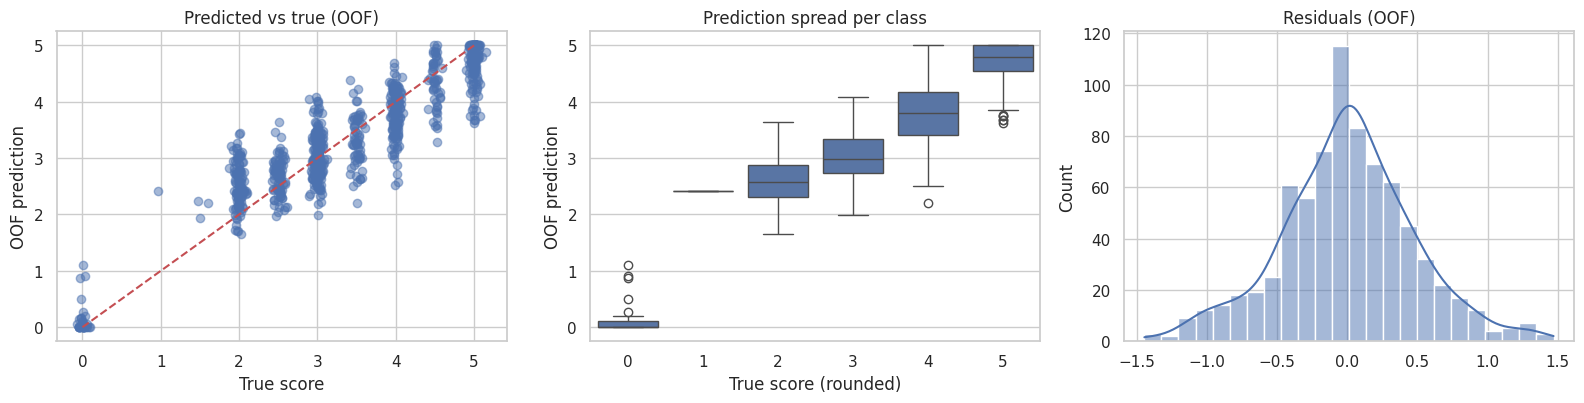

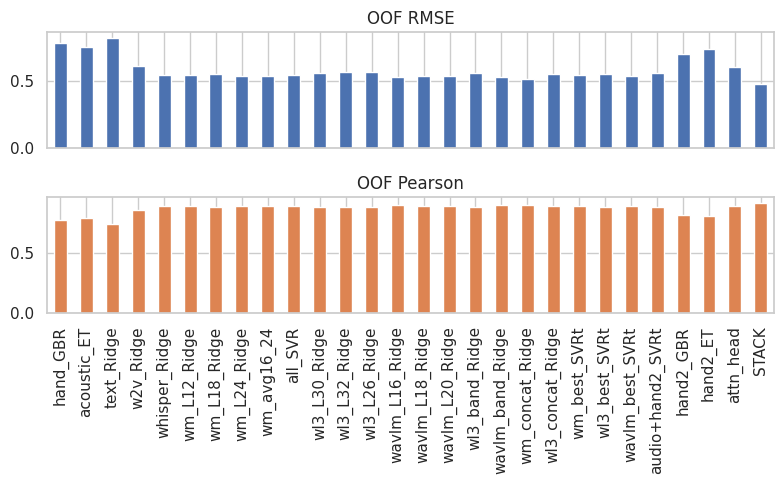

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].scatter(y + np.random.normal(0, .04, len(y)), oof_final, alpha=.5); ax[0].plot([0, 5], [0, 5], "r--")
ax[0].set(xlabel="True score", ylabel="OOF prediction", title="Predicted vs true (OOF)")
sns.boxplot(x=pd.Series(y).round().astype(int), y=oof_final, ax=ax[1]); ax[1].set(xlabel="True score (rounded)", ylabel="OOF prediction", title="Prediction spread per class")
sns.histplot(y - oof_final, kde=True, ax=ax[2]); ax[2].set(title="Residuals (OOF)")
plt.tight_layout(); plt.show()

cmp = pd.DataFrame({n: [rmse(y, np.clip(OOF[n], 0, 5)), pearsonr(y, OOF[n])[0]] for n in names} | {"STACK": [rmse(y, oof_final), pearsonr(y, oof_final)[0]]}, index=["RMSE", "Pearson"]).T
cmp.plot.bar(subplots=True, figsize=(8, 5), legend=False, title=["OOF RMSE", "OOF Pearson"]); plt.tight_layout(); plt.show()

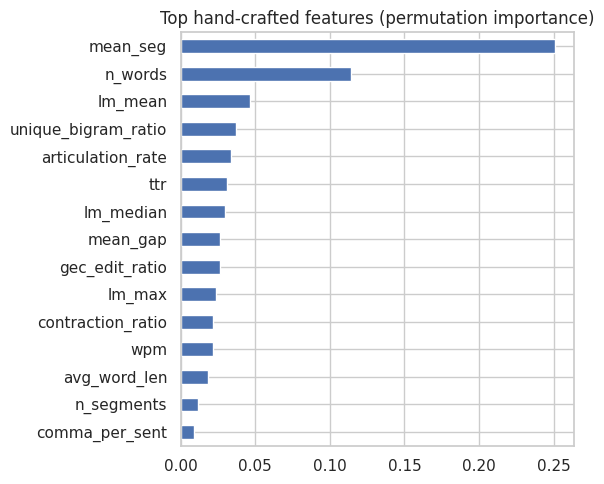

In [24]:
# Interpretability: permutation importance of hand-crafted features inside the GBR block (OOF-style, one hold-out split)
from sklearn.inspection import permutation_importance
tr_i, va_i = next(KFold(5, shuffle=True, random_state=SEED).split(X_hand_tr))
g = blocks["hand_GBR"][2]().fit(X_hand_tr.values[tr_i], y[tr_i])
pi = permutation_importance(g, X_hand_tr.values[va_i], y[va_i], n_repeats=15, random_state=SEED, scoring="neg_root_mean_squared_error")
imp = pd.Series(pi.importances_mean, index=X_hand_tr.columns).sort_values().tail(15)
imp.plot.barh(figsize=(6, 5), title="Top hand-crafted features (permutation importance)"); plt.tight_layout(); plt.show()

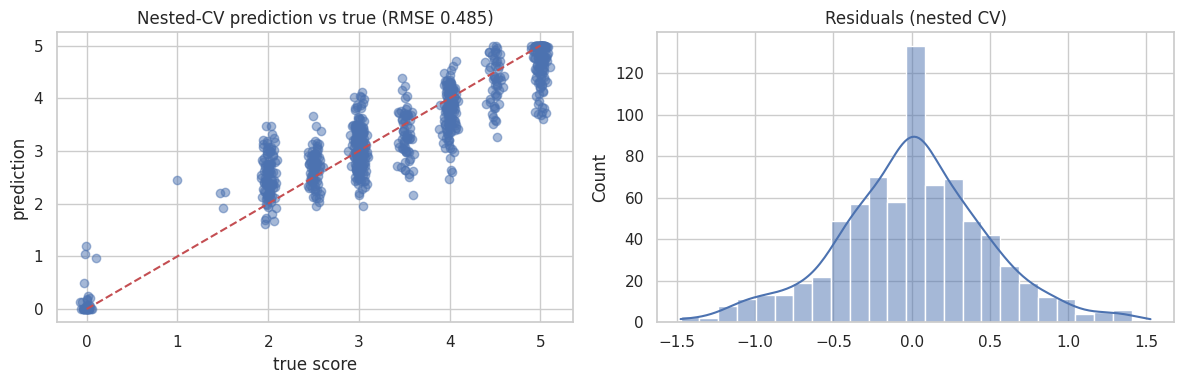

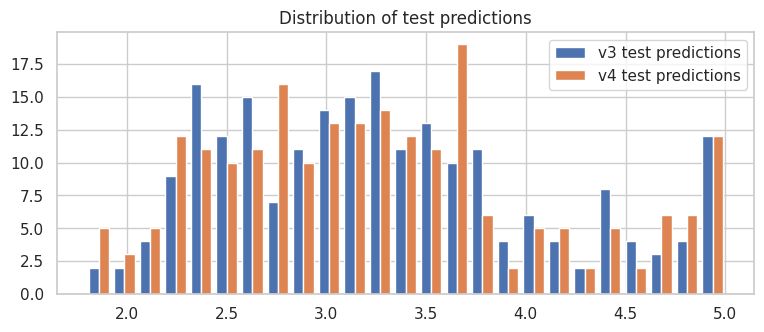

In [25]:
# Nested-CV view (the most honest estimate) and encoder comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(y + np.random.normal(0, .04, len(y)), cv_pred, alpha=.5); ax[0].plot([0, 5], [0, 5], "r--")
ax[0].set(title=f"Nested-CV prediction vs true (RMSE {cv_rmse:.3f})", xlabel="true score", ylabel="prediction")
sns.histplot(y - cv_pred, kde=True, ax=ax[1]); ax[1].set(title="Residuals (nested CV)"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist([v3_test, test_final], bins=25, label=["v3 test predictions", "v4 test predictions"]); ax.legend(); ax.set(title="Distribution of test predictions")
plt.show()

## 7. Create submission

In [26]:
# Predictions are mapped by filename. Follow sample_submission's order only if its filenames match test.csv exactly.
pred_map = dict(zip(test[FILE_COL], test_final))
overlap = len(set(sub[FILE_COL]) & set(test[FILE_COL])) if FILE_COL in sub.columns else 0
print(f"Filename overlap between sample_submission and test.csv: {overlap}/{len(test)}")
base = sub[[FILE_COL]] if overlap == len(test) else test[[FILE_COL]]
if overlap != len(test): print("WARNING: sample_submission filenames differ from test.csv; using test.csv (check the Data tab / rules).")
out = base.copy(); out[LABEL_COL] = out[FILE_COL].map(pred_map).values
assert out[LABEL_COL].notna().all() and out[FILE_COL].is_unique and out[LABEL_COL].between(0, 5).all()
out.to_csv("/kaggle/working/submission.csv", index=False)
print(out.shape); out.head()

Filename overlap between sample_submission and test.csv: 25/216
(216, 2)


,filename,label
0,audio_128.wav,2.825180
1,audio_156.wav,4.169652
2,audio_19.wav,4.647200
3,audio_108.wav,1.839083
4,audio_206.wav,2.193909


### 7b. Extra files (variants and two diagnostics)
- `submission_v3.csv`: your previous model, `submission_blend.csv`: 50/50 average of v3 and v4 (a hedge).
- **Diagnostics, do not submit as final:** `probe_constant.csv` (all rows = one value) and `probe_shrunk_v3.csv` (v3 predictions shrunk 50% toward their mean, which leaves Pearson unchanged). Submitting these two tells us what the leaderboard score really measures (RMSE only, or something combined).

In [27]:
def write_sub(pred, fname):
    o = test[[FILE_COL]].copy(); o[LABEL_COL] = np.clip(pred, 0, 5)
    assert o[LABEL_COL].notna().all() and o[FILE_COL].is_unique
    o.to_csv(f"/kaggle/working/{fname}", index=False); print("saved", fname, o.shape)

write_sub(v3_test, "submission_v3.csv")
write_sub(0.5 * test_final + 0.5 * v3_test, "submission_blend.csv")
m_ = float(v3_test.mean())
write_sub(np.full(len(test), m_), "probe_constant.csv")
write_sub(m_ + 0.5 * (v3_test - m_), "probe_shrunk_v3.csv")
print("corr(v4, v3) on test =", np.corrcoef(test_final, v3_test)[0, 1].round(4))

saved submission_v3.csv (216, 2)
saved submission_blend.csv (216, 2)
saved probe_constant.csv (216, 2)
saved probe_shrunk_v3.csv (216, 2)
corr(v4, v3) on test = 0.9851


In [28]:
from IPython.display import Markdown, display
_best = pd.Series({n: rmse(y, np.clip(OOF[n], 0, 5)) for n in names}).sort_values()
display(Markdown(f"""
## 8. Report (numbers are filled in automatically from this run)

**Task.** Predict a continuous 0-5 MOS grammar score from a 45-60 s speech clip; {len(train)} training and {len(test)} test clips; metrics RMSE and Pearson.

**Preprocessing.** Audio is loaded at 16 kHz mono and peak-normalised. Whisper-small gives a plain transcript; Whisper-medium with a disfluent prompt gives a verbatim transcript plus token-confidence features. Silence segmentation yields pause and speech-rate features.

**Pipeline architecture.**
1. *Hand-crafted block:* sentence/lexical/disfluency statistics, prosody, GPT-2 perplexity (plain and verbatim transcript), ASR confidence, grammar-error-correction edit ratio -> gradient boosting and extra-trees.
2. *Text embeddings:* RoBERTa transcript embedding -> Ridge.
3. *Audio embeddings:* wav2vec2, Whisper-small, Whisper-medium, Whisper-large-v3 and WavLM-large (layer-wise mean+std pooled) -> Ridge and grid-search-tuned SVR; several layers were scanned and the best ones kept.
4. *Neural head:* a small attention-pooling transformer over frame-level Whisper features ({FR_NAME.split('/')[-1]}, layers {FR_LAYERS}).
5. *Stacker:* non-negative least squares on out-of-fold predictions ({len(sel_names)} blocks selected by nested CV, linear calibration = {best_cal}); output clipped to [0, 5].

**Validation.** 3x repeated 5-fold CV produces out-of-fold (OOF) predictions for every block. The stacker itself is evaluated with nested CV, which is the most honest estimate.

| Split | RMSE | Pearson |
|---|---|---|
| Mean-prediction baseline | {rmse(y, np.full_like(y, y.mean())):.4f} | n/a |
| **Training data (fit on all, evaluated on same) - required** | **{rmse(y, train_final):.4f}** | {pearsonr(y, train_final)[0]:.4f} |
| OOF of the final blend | {rmse(y, oof_final):.4f} | {pearsonr(y, oof_final)[0]:.4f} |
| **Nested-CV estimate (honest)** | **{cv_rmse:.4f}** | {pearsonr(y, cv_pred)[0]:.4f} |
| Previous v3 stack (OOF) | {rmse(y, v3_oof):.4f} | {pearsonr(y, v3_oof)[0]:.4f} |

The gap between training RMSE and the OOF/nested-CV RMSE shows the models fit the training labels more tightly than unseen data, so the nested-CV figure is the realistic one.

**Best single blocks (OOF RMSE):** {', '.join(f'{n} {v:.3f}' for n, v in _best.head(6).items())}.

**Findings.** Audio-encoder representations beat transcript-only ones, probably because ASR output removes disfluencies and small errors that a grammar rater would hear; the verbatim transcript, ASR confidence and the GEC edit ratio were added to recover part of that signal. The learned attention-pooling head and the stack combine different views of the same audio.

**Interpretation.** The Spearman bar chart, permutation importance and layer-scan plots show which signals matter: sentence length and complexity, lexical variety, LM perplexity, pauses and ASR confidence, and middle-to-upper encoder layers.

**Limitations / next steps.** Only 769 training clips, so neural heads and large embeddings are prone to overfitting (hence repeated CV, weight decay, frame dropout and seed averaging). Labels are noisy ordinal scores. Possible next steps: fine-tune the top Whisper encoder layers, ordinal-aware losses, more seeds for the neural head.
"""))


## 8. Report (numbers are filled in automatically from this run)

**Task.** Predict a continuous 0-5 MOS grammar score from a 45-60 s speech clip; 769 training and 216 test clips; metrics RMSE and Pearson.

**Preprocessing.** Audio is loaded at 16 kHz mono and peak-normalised. Whisper-small gives a plain transcript; Whisper-medium with a disfluent prompt gives a verbatim transcript plus token-confidence features. Silence segmentation yields pause and speech-rate features.

**Pipeline architecture.**
1. *Hand-crafted block:* sentence/lexical/disfluency statistics, prosody, GPT-2 perplexity (plain and verbatim transcript), ASR confidence, grammar-error-correction edit ratio -> gradient boosting and extra-trees.
2. *Text embeddings:* RoBERTa transcript embedding -> Ridge.
3. *Audio embeddings:* wav2vec2, Whisper-small, Whisper-medium, Whisper-large-v3 and WavLM-large (layer-wise mean+std pooled) -> Ridge and grid-search-tuned SVR; several layers were scanned and the best ones kept.
4. *Neural head:* a small attention-pooling transformer over frame-level Whisper features (whisper-medium, layers [22, 23, 24]).
5. *Stacker:* non-negative least squares on out-of-fold predictions (27 blocks selected by nested CV, linear calibration = True); output clipped to [0, 5].

**Validation.** 3x repeated 5-fold CV produces out-of-fold (OOF) predictions for every block. The stacker itself is evaluated with nested CV, which is the most honest estimate.

| Split | RMSE | Pearson |
|---|---|---|
| Mean-prediction baseline | 1.2382 | n/a |
| **Training data (fit on all, evaluated on same) - required** | **0.1536** | 0.9924 |
| OOF of the final blend | 0.4764 | 0.9234 |
| **Nested-CV estimate (honest)** | **0.4850** | 0.9207 |
| Previous v3 stack (OOF) | 0.5086 | 0.9156 |

The gap between training RMSE and the OOF/nested-CV RMSE shows the models fit the training labels more tightly than unseen data, so the nested-CV figure is the realistic one.

**Best single blocks (OOF RMSE):** wm_concat_Ridge 0.519, wavlm_band_Ridge 0.527, wavlm_L16_Ridge 0.528, wavlm_best_SVRt 0.534, wavlm_L18_Ridge 0.534, wm_L24_Ridge 0.535.

**Findings.** Audio-encoder representations beat transcript-only ones, probably because ASR output removes disfluencies and small errors that a grammar rater would hear; the verbatim transcript, ASR confidence and the GEC edit ratio were added to recover part of that signal. The learned attention-pooling head and the stack combine different views of the same audio.

**Interpretation.** The Spearman bar chart, permutation importance and layer-scan plots show which signals matter: sentence length and complexity, lexical variety, LM perplexity, pauses and ASR confidence, and middle-to-upper encoder layers.

**Limitations / next steps.** Only 769 training clips, so neural heads and large embeddings are prone to overfitting (hence repeated CV, weight decay, frame dropout and seed averaging). Labels are noisy ordinal scores. Possible next steps: fine-tune the top Whisper encoder layers, ordinal-aware losses, more seeds for the neural head.
